In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
df = pd.read_excel("../data/Sales Records.csv.xlsx")
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,South Africa,Fruits,Offline,M,7/27/2012,443368995,7/28/2012,1593,9.33,6.92,14862.69,11023.56,3839.13
1,Middle East and North Africa,Morocco,Clothes,Online,M,9/14/2013,667593514,10/19/2013,4611,109.28,35.84,503890.08,165258.24,338631.84
2,Australia and Oceania,Papua New Guinea,Meat,Offline,M,5/15/2015,940995585,2015-04-06 00:00:00,360,421.89,364.69,151880.40,131288.40,20592.00
3,Sub-Saharan Africa,Djibouti,Clothes,Offline,H,5/17/2017,880811536,2017-02-07 00:00:00,562,109.28,35.84,61415.36,20142.08,41273.28
4,Europe,Slovakia,Beverages,Offline,L,10/26/2016,174590194,2016-04-12 00:00:00,3973,47.45,31.79,188518.85,126301.67,62217.18


In [233]:
print("Total number of rows:", df.shape[0])
print("Total number of columns:", df.shape[1])

Total number of rows: 500000
Total number of columns: 14


In [234]:
df.columns 
df.dtypes

Region             object
Country            object
Item Type          object
Sales Channel      object
Order Priority     object
Order Date         object
Order ID            int64
Ship Date          object
Units Sold          int64
Unit Price        float64
Unit Cost         float64
Total Revenue     float64
Total Cost        float64
Total Profit      float64
dtype: object

In [235]:
df.columns

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='object')

In [236]:
print(df.dtypes)

Region             object
Country            object
Item Type          object
Sales Channel      object
Order Priority     object
Order Date         object
Order ID            int64
Ship Date          object
Units Sold          int64
Unit Price        float64
Unit Cost         float64
Total Revenue     float64
Total Cost        float64
Total Profit      float64
dtype: object


In [237]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [238]:
column_summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

column_summary

,Column Name,Data Type
0,Region,object
1,Country,object
2,Item Type,object
3,Sales Channel,object
4,Order Priority,object
5,Order Date,datetime64[ns]
6,Order ID,int64
7,Ship Date,datetime64[ns]
8,Units Sold,int64
9,Unit Price,float64


In [239]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
datetime_columns = df.select_dtypes(include=["datetime64"]).columns.tolist()

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)
print("Datetime columns:", datetime_columns)

Numerical columns: ['Order ID', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit']
Categorical columns: ['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority']
Datetime columns: ['Order Date', 'Ship Date']


## 1. Data Preparation. 

 -- First, Loaded the Dataset into pandas DataFrame using `pd.read_excel()`. After loading the file, `df.head()` was used to see the first five rows of the dataset. This helps us to check what kind of data are presented in the dataset and if the dataset was loaded correctly.
 -- The DataFrame now contains Sales Records from different regions and countries where eaxh row represented one sales order and column represented details such as item type, sales channels, order priority, order date, units sold, revenue, cost and profit. 
 -- By using `df.shape ` we got to know the size of the dataset and using `df.columns`, `df.dtypes`, we got to know the column names and data types. 
 -- The columns were then separated into numerical, categorical and datatime variables. The Data columns with `Order date` and `ship data` were converted into proper datatime format to make them easy for time-based analysis. 
 -- The dataset is suitable For Exploratory Data Analysis because it includes numerical, categorical and datetime variables. This helps us to study the sales performance from different angles such as profit, revenue, item type, regions and sales channels. 
 -- There is no fixed target variable in this dataset because this project focuses on EDA rather than supervisied machine learning but if the dataset was later used for prediction then the `Total Profit` could be treated as possible target variable. 

## Data Cleaning. 
### Missing Values 
-- Missing values were checked in every column to see whether any data was incomplete.

In [240]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Values,Missing Percentage
Region,0,0.0
Country,0,0.0
Item Type,0,0.0
Sales Channel,0,0.0
Order Priority,0,0.0
Order Date,0,0.0
Order ID,0,0.0
Ship Date,0,0.0
Units Sold,0,0.0
Unit Price,0,0.0


### Duplicate Records

Duplicate records were checked to make sure that the same sales transaction was not counted more than once.

In [241]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows found:", duplicate_count)

df_cleaned = df.drop_duplicates()

print("Number of duplicate rows removed:", duplicate_count)
print("New dataset shape after duplicate removal:", df_cleaned.shape)

Number of duplicate rows found: 0
Number of duplicate rows removed: 0
New dataset shape after duplicate removal: (500000, 14)


## Results of Duplicate Records
The duplicate check showed that there were 0 duplicate rows in the dataset. so, no duplicate records were removed. After checking duplicates, the dataset shape was same as before (i.e. 500,000 rows and 14 columns). This means each sales transaction in the dataset is unique.

###  Finding Outliners by Using IQR

-- we need to use the IQR method for two numerical columns which are `Units Sold` and `Total Profit`. Both were selected for outliners analysis because they are important for understanding sales quantity and profitability.

In [242]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)

selected_columns = ["Units Sold", "Total Profit"]

for column in selected_columns:
    Q1, Q3, IQR, lower_bound, upper_bound, outlier_count = detect_outliers_iqr(df_cleaned, column)
    
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outliers:", outlier_count)
    print("-" * 40)

Column: Units Sold
Q1: 2502.0
Q3: 7497.0
IQR: 4995.0
Lower Bound: -4990.5
Upper Bound: 14989.5
Number of outliers: 0
----------------------------------------
Column: Total Profit
Q1: 95385.06
Q3: 565392.28
IQR: 470007.22000000003
Lower Bound: -609625.77
Upper Bound: 1270403.11
Number of outliers: 20867
----------------------------------------


## Outlier Results
The IQR method was used for `Units Sold` and `Total Profit`. For `Units Sold`, we get lower bound -4990.5 and the upper bound 14989.5 with 0 outliers detected which means the sales quantity values are within the expected range according to the IQR method.

For `Total Profit`, the lower bound was -609625.77 and the upper bound was 1270403.11. A total outliners were 20,867. These outliers were retained because they may represent legitimate high-profit sales transactions rather than data entry errors. Since large orders can naturally generate high profit. So, removing these records could reduce the usefulness of the dataset for sales analysis.

### Summary of Data Cleaning

During the data cleaning process, we checked for missing values, duplicate records and outliers. The missing value analysis showed that all columns had 0 missing values, so no missing value treatment was needed. The duplicate check showed that there were 0 duplicate rows, so no duplicate records were removed and the dataset shape was as before 500,000 rows and 14 columns.

 IQR method was used to find out the Outliners. It was used on `Units Sold` and `Total Profit`. No outliers were found in `Units Sold` while 20,867 outliers were found in `Total Profit`. These profit outliers were retained because they may represent valid high-profit sales transactions. Removing them could remove important business information from the dataset thats why we retained it. 

### Single Column Analysis

A single numerical column and a single categorical column were analysed to understand their individual distribution. For this we have chosen `Total profit` for Numerical column and `Item Type` for categorical column. 

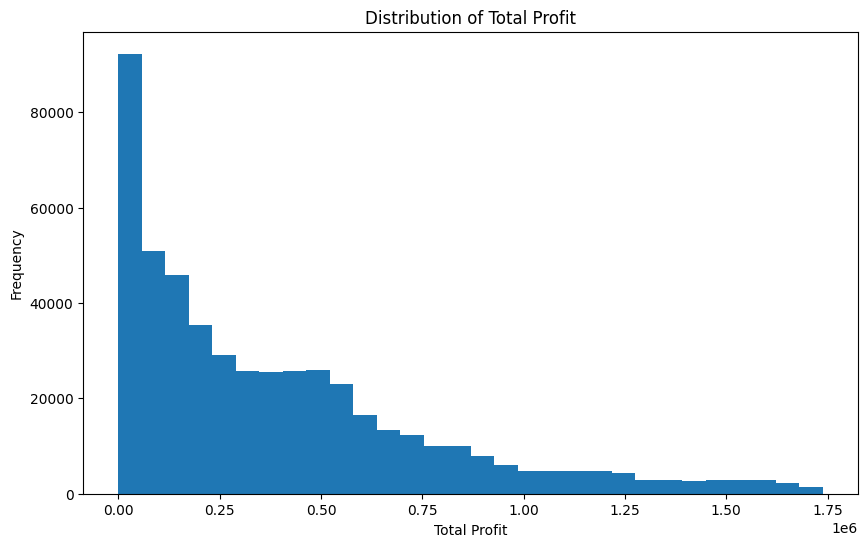

In [243]:
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned["Total Profit"], bins=30)
plt.title("Distribution of Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Frequency")
plt.show()

## Numerical Column Results
The histogram of `Total Profit` shows that most sales transactions have lower to medium profit values while fewer transactions have very high profit values. The distribution is right-skewed which means most values are smaller but some values stretch far to high side. This supports the earlier outlier analysis where high-profit outliers were detected.

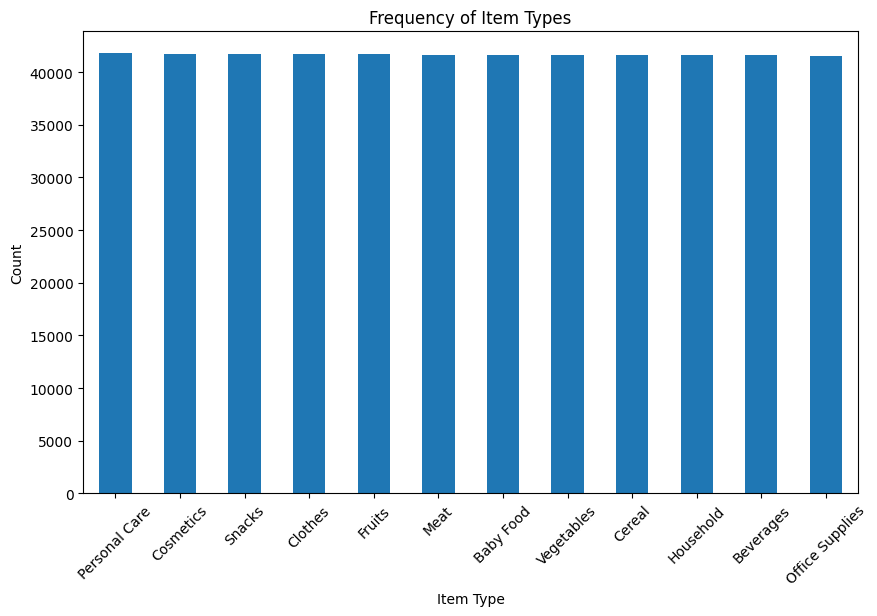

In [244]:
plt.figure(figsize=(10, 6))
df_cleaned["Item Type"].value_counts().plot(kind="bar")
plt.title("Frequency of Item Types")
plt.xlabel("Item Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

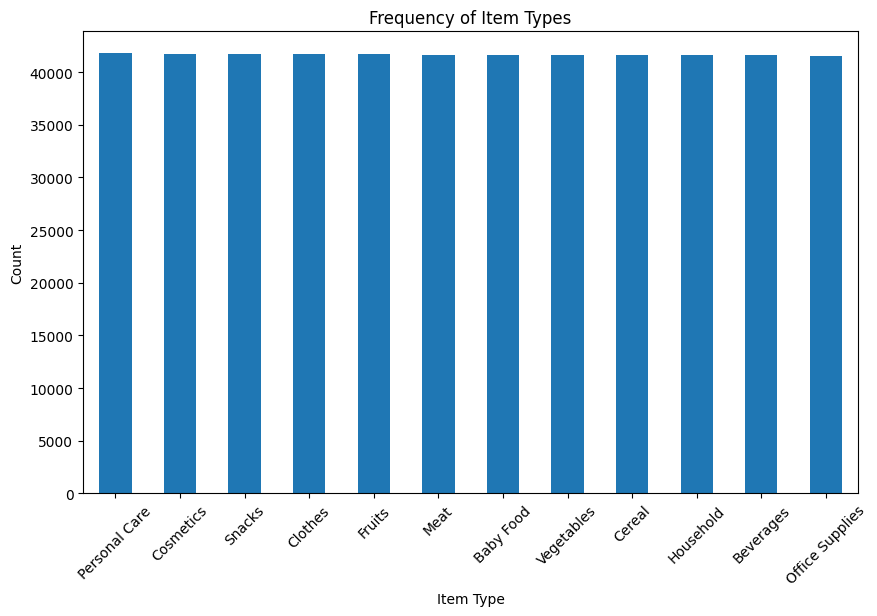

In [245]:
plt.figure(figsize=(10, 6))
df_cleaned["Item Type"].value_counts().plot(kind="bar")
plt.title("Frequency of Item Types")
plt.xlabel("Item Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [246]:
item_counts = df_cleaned["Item Type"].value_counts()

print("Most common item type:", item_counts.idxmax(), "-", item_counts.max())
print("Least common item type:", item_counts.idxmin(), "-", item_counts.min())

Most common item type: Personal Care - 41789
Least common item type: Office Supplies - 41578


## Categorical Column outputs 
The bar chart of `Item Type` shows how frequently each product category appears in the dataset. The item type with the highest count is the most common product category in the sales records while the item type with the lowest count is the least common. Overall, the chart helps compare product category distribution and shows whether some item types appear more often than others. Here, the most common item type is Personal Care and the least common item is Office Suppiles.

### Relationship Between Two Columns

A correlation heatmap was created to examine the relationship between numerical columns in the dataset.

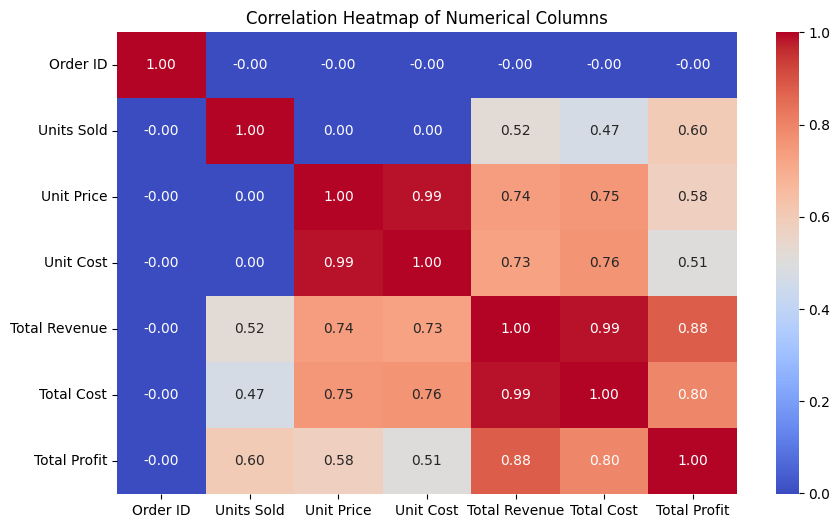

In [247]:
numeric_df = df_cleaned.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

**Correlation Heatmap Output**  
The correlation heatmap shows the strength of relationships between numerical variables. The strongest relationship was found between `Unit Price` and `Unit Cost` with a correlation value of 0.99. This means that products with higher selling prices also tend to have higher unit costs. Another very strong relationship was between `Total Revenue` and `Total Cost` which was also around 0.99 which suggests that higher revenue is usually connected with higher cost. `Total Revenue` and `Total Profit` also had a strong positive relationship of 0.88 which means higher revenue generally leads to higher profit.

In [248]:
corr_pairs = correlation_matrix.unstack()

# Remove self-correlation values where correlation is exactly 1
corr_pairs = corr_pairs[corr_pairs < 1]

# Sort values from strongest to weakest
strongest_corr = corr_pairs.sort_values(ascending=False).head(1)

print("Strongest correlation:")
print(strongest_corr)

Strongest correlation:
Total Cost  Total Revenue    0.987715
dtype: float64


### Scatter Plot: Total Revenue vs Total Profit

A scatter plot was created to visually examine the relationship between `Total Revenue` and `Total Profit`.

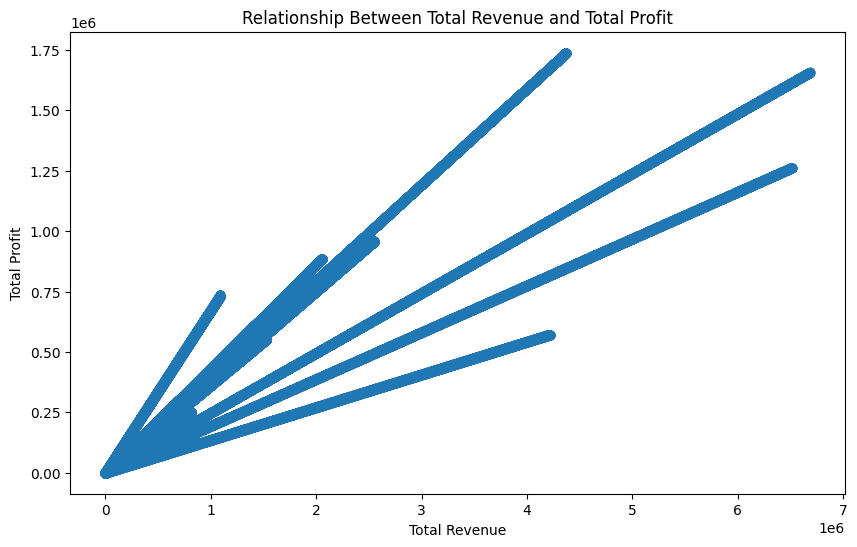

In [249]:
plt.figure(figsize=(10, 6))

plt.scatter(df_cleaned["Total Revenue"], df_cleaned["Total Profit"], alpha=0.3)

plt.title("Relationship Between Total Revenue and Total Profit")
plt.xlabel("Total Revenue")
plt.ylabel("Total Profit")
plt.show()

**Scatter Plot Outputs**  
The scatter plot between `Total Revenue` and `Total Profit` shows a clear positive relationship. As total revenue increases, total profit also generally increases. The points appear in diagonal patterns which may be due to different product types having different profit margins. This supports the correlation heatmap result where `Total Revenue` and `Total Profit` had a strong positive correlation.

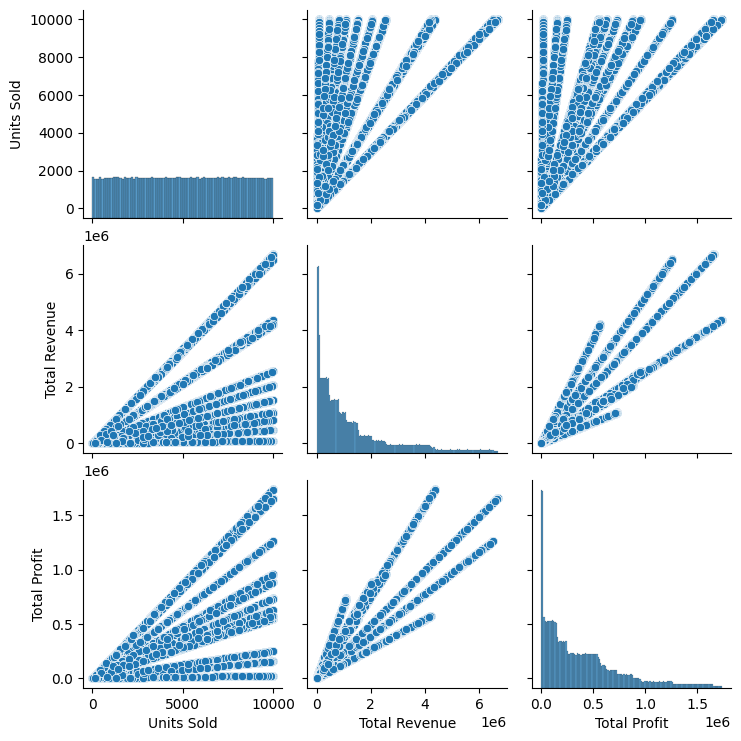

In [250]:
selected_pairplot_columns = ["Units Sold", "Total Revenue", "Total Profit"]

sns.pairplot(df_cleaned[selected_pairplot_columns])
plt.show()

**Pair Plot outputs:**  
The pair plot shows that `Total Revenue` and `Total Profit` have a clear positive relationship as the points generally move upward together which basically means that higher revenue is usually connected with higher profit. The diagonal distribution plots show that `Total Revenue` and `Total Profit` are right-skewed with many lower values and fewer very high values. The line-like patterns in the scatter plots may be caused by different product types, unit prices or profit margins. This insight is useful because it shows that profit is influenced by both sales volume and revenue patterns.

### Summary of Findings

The single-column analysis showed that `Total Profit` is right-skewed with most transactions having lower to medium profit values and fewer transactions having very high profit values. The categorical analysis of `Item Type` showed that product categories are not evenly distributed which means some item types appear more frequently than others.

The correlation heatmap showed that the strongest relationship was between `Unit Price` and `Unit Cost` with a correlation value of 0.99. This means that products with higher selling prices usually also have higher unit costs. The scatter plot between `Total Revenue` and `Total Profit` also showed a strong positive relationship which means higher revenue generally leads to higher profit.

The pair plot showed similar upward patterns between `Total Revenue`, `Total Profit` and `Units Sold`. Overall, the dataset shows clear relationships between sales quantity, revenue, cost and profit, making it useful for understanding sales performance and preparing for possible future machine learning analysis.

## Conclusion

### Key Findings

The analysis showed that `Total Profit` is right-skewed which means most sales transactions have lower to medium profit values while fewer transactions have very high profit values. The histogram also supported the outlier analysis where high-profit outliers were detected in the `Total Profit` column.

The correlation heatmap showed a very strong positive relationship between `Unit Price` and `Unit Cost` with a correlation value of 0.99. This suggests that products with higher selling prices also usually have higher costs. A strong positive relationship was also found between `Total Revenue` and `Total Profit`, showing that higher revenue generally contributes to higher profit.

The categorical analysis showed that item types are not evenly distributed across the dataset. Some item types appeared more frequently than others which may be useful for understanding product demand and sales patterns.

### Data Quality Assessment

The dataset was mostly clean. There were no missing values and no duplicate records. The dataset shape remained 500,000 rows and 14 columns after duplicate checking. Outliers were found in `Total Profit` but they were retained because they may represent valid high-profit transactions rather than errors. However, these outliers should still be considered carefully in future machine learning work because they may influence model performance.

### Possible Machine Learning Questions

One possible machine learning question is: Can `Total Profit` be predicted using variables such as `Units Sold`, `Unit Price`, `Unit Cost`, `Total Revenue` and `Total Cost`? This is possible because the correlation heatmap showed strong relationships between revenue, cost and profit.

Another possible question is: Can sales records be grouped or classified based on item type, sales channel, region or profitability level? This could help identify different sales patterns and support business decision-making.

### Final Verdict

Overall, the dataset is suitable for Exploratory Data Analysis and mostly ready for future modelling. Before building a machine learning model, additional steps such as feature scaling, encoding categorical variables, checking class imbalance and validating outlier treatment would be recommended.